# Coding 1：环境检查、收益率工程与组合展示

对应源文件：`coding_1.py`。按作业模块整理。

## 题目一：环境与系统检查

- 目标是确认 Python、核心包和工作目录是否可用。
- `dir(numpy_financial)` 用于探索金融计算库的函数，例如 `npv`、`irr`、`pv`、`rate`。
- 这类环境检查不是金融模型本身，但能避免后续作业因路径和包版本失败。

In [ ]:
import os
import sys
import pandas as pd
import numpy as np
import yfinance as yf
import scipy.stats as stats
import numpy_financial as npf
import matplotlib.pyplot as plt

'''检查当前工作目录，并创建课程练习文件夹。'''
current_directory = os.getcwd()
exercise_path = os.path.join(current_directory, 'Class_Exercise')
os.makedirs(exercise_path, exist_ok=True)
print(f'Current Directory: {current_directory}')
print(f'Exercise Directory: {exercise_path}')

'''检查 Python 与关键包版本，保证作业运行环境可复现。'''
print(f'Python version: {sys.version}')
print(f'pandas: {pd.__version__}')
print(f'numpy: {np.__version__}')
print(f'yfinance: {yf.__version__}')
print('Functions in numpy_financial:', [name for name in dir(npf) if not name.startswith('_')][:20])

## 题目二：多股票数据清洗与季度收益率

- 多股票行情通常用列表示股票、行表示交易日。
- 缺失值可能来自停牌、上市时间差异或数据源问题；前向填充适合价格序列，但不适合随意填充收益率。
- 季度收益率应由日收益率复利得到。

In [ ]:
import numpy as np
import pandas as pd

np.random.seed(2026)
tickers = ['AAPL', 'MSFT', 'GOOGL']
dates = pd.bdate_range('2024-01-01', '2026-03-19')
price_data = pd.DataFrame(
    100 * np.exp(np.cumsum(np.random.normal(0.0005, 0.015, (len(dates), len(tickers))), axis=0)),
    index=dates,
    columns=tickers,
)

'''模拟少量缺失值，用 forward fill 处理价格缺口。'''
price_data.iloc[5, 0] = np.nan
missing_before_cleaning = price_data.isnull().sum()
clean_price_data = price_data.ffill().dropna()

'''季度收益率：先算对数收益，再按年份和季度加总并还原。'''
log_returns = np.log(clean_price_data / clean_price_data.shift(1))
log_returns['Year'] = log_returns.index.year
log_returns['Quarter'] = log_returns.index.quarter
quarterly_returns = np.exp(log_returns.groupby(['Year', 'Quarter']).sum()) - 1
print(missing_before_cleaning)
print(quarterly_returns.head())

## 题目三：统计比较、Sharpe Ratio 与成长曲线

- 双样本 t 检验用于比较两只股票平均日收益是否有显著差异。
- Sharpe Ratio 是单位总风险带来的超额收益，常用于横向比较资产或策略。
- 累计收益曲线把 `1 元初始投资` 随时间复利增长的过程可视化。

In [ ]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

returns = clean_price_data.pct_change().dropna()

'''比较 AAPL 与 MSFT 的平均日收益是否显著不同。'''
t_statistic, p_value = stats.ttest_ind(returns['AAPL'], returns['MSFT'], equal_var=False)
print(p_value)
print('significant' if p_value < 0.05 else 'not significant')

'''年化 Sharpe Ratio：日均超额收益 / 日波动率，再乘 sqrt(252)。'''
annual_risk_free_rate = 0.01
daily_risk_free_rate = (1 + annual_risk_free_rate) ** (1 / 252) - 1
excess_returns = returns - daily_risk_free_rate
sharpe_ratio = excess_returns.mean() / excess_returns.std() * np.sqrt(252)
print(sharpe_ratio)

cumulative_returns = (1 + returns).cumprod()
cumulative_returns.plot(figsize=(10, 5), title='Growth of $1')
plt.xlabel('Date')
plt.ylabel('Value')
plt.show()

**结果复现：累计成长曲线**

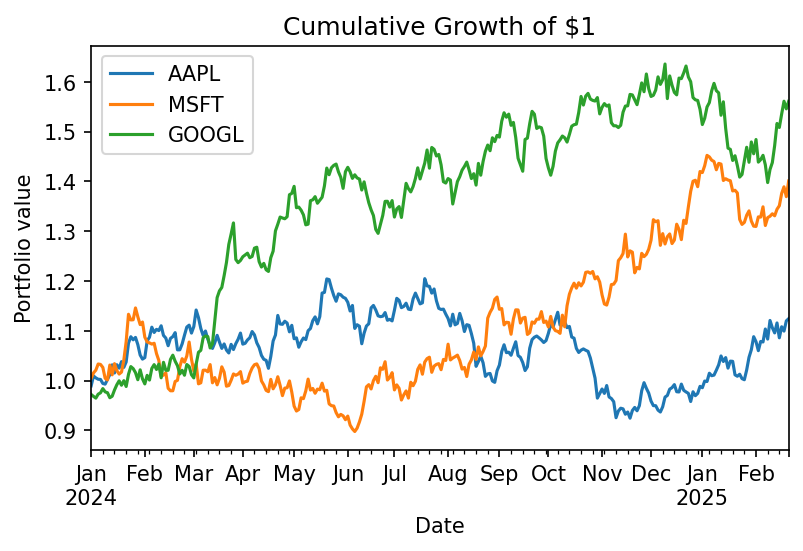

- 三条线代表三只股票从同一起点开始的复利成长路径。
- 模拟年化均值约为 `{'AAPL': 0.125, 'MSFT': 0.317, 'GOOGL': 0.404}`，年化波动约为 `{'AAPL': 0.232, 'MSFT': 0.262, 'GOOGL': 0.245}`。
- 复习时要把 Sharpe Ratio 和图结合看：高收益若伴随更高波动，未必是更优资产。